# 📘 Домашнє завдання №19. Задача кластеризації: DBSCAN, ієрархічна кластеризація

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW19


## 1. Застосувати K-Means

### Необхідно:
- навчити модель K-Means
- використати `n_clusters=3`
- візуалізувати результати кластеризації
- показати центроїди кластерів

---

## 2. Застосувати DBSCAN

### Необхідно:
- підібрати параметри:
  - `eps`
  - `min_samples`
- візуалізувати результати
- визначити:
  - кількість кластерів
  - кількість шумових точок

---

## 3. Застосувати Agglomerative Clustering

### Необхідно:
- використати:
```python
AgglomerativeClustering
```

- спробувати різні `linkage methods`:
  - `ward`
  - `complete`
  - `average`

- порівняти результати

---

## 4. Побудувати дендрограму

### Необхідно:
- побудувати дендрограму
- пояснити:
  - як визначити кількість кластерів
  - що означають великі вертикальні відстані

---

## 5. Обчислити метрики якості

Для кожного алгоритму обчислити:

### Внутрішні метрики:
- Silhouette Score
- Calinski-Harabasz Index
- Davies-Bouldin Index

### Зовнішні метрики:
(оскільки справжні мітки відомі)
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "kagglehub[pandas-datasets]",
    "numpy",
    "matplotlib",
    "scipy",
    "statsmodels",
    "joblib",
    "seaborn",
    "kneed",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [ ]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input data
hm_version = 19

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone data
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

## ✳️ Підготовка датасетів

In [2]:
# Data synthesis

import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
from IPython.display import display
from IPython.core.display import Markdown

# Input data
rng_seed = 42
f1_col_name = "Feature 1"
f2_col_name = "Feature 2"
y_col_name = "Cluster ID"

# Solution
pd.options.display.float_format = "{:g}".format
np.random.seed(rng_seed)

# Генерація основних кластерів
X_data, Y_data = make_blobs(
    n_samples=470,
    centers=3,
    cluster_std=1.0,
    random_state=rng_seed
)

# Генерація шуму
noise = np.random.uniform(
    low=-15,
    high=15,
    size=(30, 2)
)

# Об'єднання кластерів та шуму
X_data = np.vstack([X_data, noise])

# Мітки для шуму
noise_labels = [-1] * len(noise)  # type: ignore

Y_data = np.concatenate([Y_data, noise_labels])

cluster_dataset = pd.DataFrame({
    f1_col_name: X_data[:, 0],
    f2_col_name: X_data[:, 1],
    y_col_name: Y_data,
})

# Print results
display(cluster_dataset.head(10).style.set_caption("Синтетичний dataset з трьома кластерами та шумом"))


,Feature 1,Feature 2,Cluster ID
0,4.152273,1.540611,1
1,-6.797343,-5.814629,2
2,5.285255,3.341801,1
3,4.737555,1.200160,1
4,-6.571825,-8.590278,2
5,-5.684581,-8.403296,2
6,2.947414,3.502720,1
7,-1.203719,9.035290,0
8,-3.499734,8.447988,0
9,-3.522029,9.328533,0


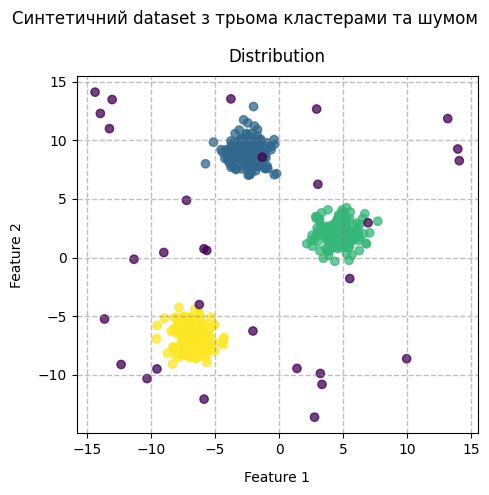

In [5]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = cluster_dataset

# Solution
_, axes = plt.subplots(figsize=(5, 5))

ax = axes
ax.scatter(x=data_set[f1_col_name], y=data_set[f2_col_name], c=data_set[y_col_name],  alpha=0.75)

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Distribution", pad=10, loc='center', color='black')
ax.set_xlabel(data_set.columns[0], labelpad=10, loc='center', color='black')
ax.set_ylabel(data_set.columns[1], labelpad=10, loc='center', color='black')


plt.suptitle("Синтетичний dataset з трьома кластерами та шумом")

plt.tight_layout()
plt.show()